In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
from scipy.stats import skew , kurtosis
import time
import tsplib95
import math

In [2]:
sys.path.append(os.path.abspath("../src"))
from populacao import Populacao
from pygenec.selecao.torneio import Torneio
from pygenec.cruzamento.edge_recombination import Edge_recombination
from pygenec.cruzamento.unponto import UmPonto

from pygenec.mutacao.inversion import Inversion
from pygenec.mutacao.swap import Swap

from pygenec.busca_local.opt_2 import Opt_2

from evolucao import Evolucao
from evolucao_tsp_classico import Evolucao_classica

from funcoes import Criar_Gif, Imagens_para_gif,Ate_convergir, Melhor_rota, Numero_de_geracoes, Arredondar_cima

In [3]:
sys.path.append(os.path.abspath("../data"))
problema = tsplib95.load("..\data\TSPLIB\eil76.tsp")
solucao = tsplib95.load("..\data\TSPLIB\eil76.opt.tour")

<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\joaoa\AppData\Local\Temp\ipykernel_4268\3046378612.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  problema = tsplib95.load("..\data\TSPLIB\eil76.tsp")
C:\Users\joaoa\AppData\Local\Temp\ipykernel_4268\3046378612.py:3: SyntaxWarning: "\d" is an invalid escape sequence. Suc

In [4]:
coordenadas = problema.node_coords
rota = solucao.tours[0]
rota = np.asarray(rota)-1

In [5]:
def adjacencias (dicionario):
    dist = []
    for i in coordenadas:
        linhas = []
        for j in coordenadas:
            soma = ((dicionario[i][0]-dicionario[j][0])**2) + ((dicionario[i][1]-dicionario[j][1])**2)
            raiz = soma**(1/2)
            linhas.append(raiz)
        dist.append(linhas)
    
    return dist

def fun(individuo):
    f = 0
    n = len(individuo)
    for i in range(n-1):
        local1 = individuo[i]
        local2 = individuo[i+1]
        distancia = dist[local1][local2]
        f += distancia
    f+= dist[individuo[-1]][individuo[0]]
    return f

def avaliacao(populacao):
    tpm = []
    for ind in populacao:
        tpm.append(fun(ind))
    tpm = np.asarray(tpm)
    return tpm

In [6]:
dist = adjacencias(coordenadas)
df = pd.DataFrame.from_dict(coordenadas, orient="index", columns=["x", "y"])

In [7]:
cromossos_totais = len(coordenadas)
tamanho_populacao = 3*(cromossos_totais)
geracao = Numero_de_geracoes(cromossos_totais)
Valor_otimizador = 0.10
pmut = 0.3

## Híbrido

In [8]:
Nome = "AG Híbrido"
tam = problema.name
Juncao = Nome +" " +tam

In [9]:
populacao = Populacao(avaliacao, cromossos_totais, tamanho_populacao)
populacao.gerar_populacao()
populacao.avaliar()
selecao = Torneio(populacao)
cruzamento = Edge_recombination(tamanho_populacao)
mutacao = Inversion(pmut)
otimizador = Opt_2(dist)
evolucao = Evolucao(populacao,selecao,
                    cruzamento,mutacao,
                    otimizador,
                    Valor_otimizador,
                    geracao)

evolucao.nsele = round(tamanho_populacao/2)
evolucao.pcruz = 0.8

In [10]:
inicio = time.time()
for _ in range(geracao):
    ger, mini, melhor= evolucao.evoluir()
    print(f"Geração {ger:3d} | Melhor fitness: {mini:.2f} | Melhor rota: {melhor}")
fim = time.time()

Geração   1 | Melhor fitness: 2172.01 | Melhor rota: [54 69  3 20 34 46 59  4 39 17 61 18 36 33  5 14 75 71 11 56 67  9 16 31
 37  7  8 23 65 30 58 47 73 50  1 19 22 63  0 72 42 27 53 51 12 64 10 60
 68 70 48 55 41 32 15 57 49 21 26 44 38 35 74 62 24 45 25 66 43 29 28  2
  6 40 52 13]
Geração   2 | Melhor fitness: 2096.13 | Melhor rota: [54 69  3 20 34 46 59  4 39 17 61 18 36 33  5 14 75 71 11 56 67  9 16 31
 37  7  8 23 65 30 58 47 73 50  1 19 22 63  0 72 42 27 53 51 12 64 10 60
 68 70 48 55 41 32 15 57 49 21 26 44 38 35 74 62 24 45 25 66 43 29 28  2
  6 40 52 13]
Geração   3 | Melhor fitness: 2004.91 | Melhor rota: [29 46 36  9 20 47 53 56 43 70 18 73  8  2 15 39 31 55 63  7  5  0 69  4
 35 19 22 64 32 17 24 23 11 75 37  1 57 33 48 54 71 59 41 40 14 61 72  3
 74 67 66 45 62 42 27 28 38 16 65 30 44 26  6 21 12 52 58 13 50 10 34 25
 49 51 68 60]
Geração   4 | Melhor fitness: 2004.91 | Melhor rota: [54 13 23 15 18 73 50 11 72  0 21  8 42 27 20  1 47 14 75 71 52 40 63 60
 53 51 58 56 26 

In [11]:
evo = evolucao.historico["Melhor_fitness"].copy()
assimetria = skew(evo)
curtose = kurtosis(evo)
desvio_padrao = np.std(evo)
melhor_rota = evolucao.melhor_solucao
tempo_de_execucao = fim - inicio
Tempo_ate_convergir = Ate_convergir(evo)
Otimo_global = fun(rota)

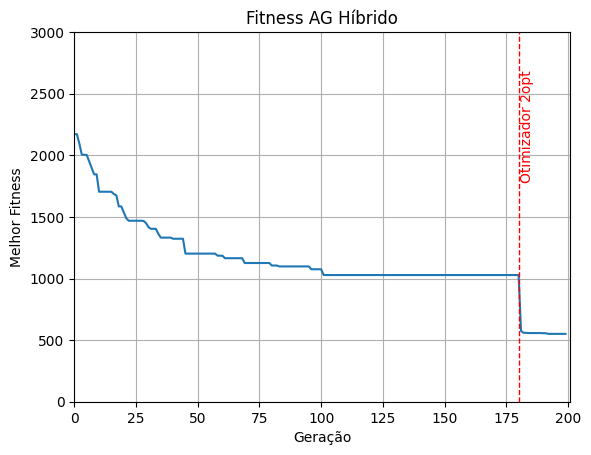

In [12]:
ROOT = os.path.abspath(os.path.join(".."))
caminhho = os.path.join(ROOT, "outputs", "graficos", f"{Juncao}.png")
linha_otmizador = geracao - (geracao*Valor_otimizador)
limite_y = Arredondar_cima(max(evo))

plt.plot(evolucao.historico["Melhor_fitness"])
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.ylim(0, limite_y)
plt.xlim(0, geracao + 1)
plt.axvline(x=linha_otmizador, color='r', linestyle='--', linewidth=1)
plt.text(linha_otmizador + 0.5, limite_y*0.6, 'Otimizador 2opt', rotation=90, color='red')
plt.title("Fitness " + Nome)
plt.grid(True)
plt.savefig(caminhho,dpi=300, bbox_inches="tight")
plt.show()

In [13]:
Imagens_para_gif(evolucao,df,tamanho_populacao,Nome)
ROOT = os.path.abspath(os.path.join(".."))
INPUT = os.path.join(ROOT, "outputs", "imagens", "*.png")
OUTPUT = os.path.join(ROOT, "outputs", "gifs", f"{Juncao}.gif")
Criar_Gif(INPUT, OUTPUT)
Melhor_rota(evolucao,df,tamanho_populacao,Juncao,Nome)

c:\Users\joaoa\OneDrive\Área de Trabalho\Project_Ag_tsp-20260315T192543Z-3-001\Project_Ag_tsp\src\funcoes.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(pasta, F"{numero+1}.png"),


### Resultados

In [14]:
print("\n" + "="*40)
print(f"RESULTADOS - {Nome}")
print("="*40)

print(f"Assimetria:             {assimetria:.4f}")
print(f"Curtose:                {curtose:.4f}")
print(f"Desvio padrão:          {desvio_padrao:.4f}")
print(f"Tempo de execução:      {tempo_de_execucao:.2f} s")
print(f"Gerações até convergir: {Tempo_ate_convergir}")

print("-"*40)
print(f"Melhor fitness:         {min(evo):.4f}")
print(f"Melhor rota encontrada:\n{melhor_rota}")
print("-"*40)
print(f"Ótimo Global:           {(Otimo_global):.4f}")
print(f"Gap:                    {(min(evo) - Otimo_global):.4f}")

print("="*40)


RESULTADOS - AG Híbrido
Assimetria:             0.7608
Curtose:                1.7058
Desvio padrão:          314.8213
Tempo de execução:      158.56 s
Gerações até convergir: 192
----------------------------------------
Melhor fitness:         550.7862
Melhor rota encontrada:
[16 11 39 31 43  2 15 62 32 72  0 21 63 41 42 40 55 22 48 23 17 49 24 54
 30  8 38 71 57  9 37 64 65 10 58 13 52  6 34  7 18 53 12 56 14  4 36 19
 69 59 70 68 35 46 20 60 27 61  1 73 29 47 28 44  3 26 51 45 33 66 25 75
 74 67  5 50]
----------------------------------------
Ótimo Global:           545.3876
Gap:                    5.3986


## Clássico

In [15]:
Nome = "AG Clássico"
tam = problema.name
Juncao = Nome +" " +tam

In [16]:
populacao = Populacao(avaliacao, cromossos_totais, tamanho_populacao)
populacao.gerar_populacao()
populacao.avaliar()
selecao= Torneio(populacao)
cruzamento = UmPonto(tamanho_populacao)
mutacao = Swap(pmut)
evolucao = Evolucao_classica(populacao,selecao,
                    cruzamento,mutacao)

evolucao.nsele = round(tamanho_populacao/2)
evolucao.pcruz = 0.8

In [17]:
inicio = time.time()
for _ in range(geracao):
    ger, mini, melhor= evolucao.evoluir()
    print(f"Geração {ger:3d} | Melhor fitness: {mini:.2f} | Melhor rota: {melhor}")
fim = time.time()

Geração   1 | Melhor fitness: 2156.80 | Melhor rota: [ 4 62 33 58 36 60 12 51 57 66 26  9 46 35 56 27 10  0 24 37 39 74  3 18
 30 48 59 14 73 20 69 11 45 25  2 72 29 75 55 23 49 65 13 19 38 71 17 43
 54 64 70 21 31 22 61  7 34 53  1 67 15 41  8 28  6 47 40 42 16 63  5 52
 44 32 68 50]
Geração   2 | Melhor fitness: 2047.44 | Melhor rota: [63 62 42 24 48 17 27 50 58 18 60 67 32 26 68  4 33 36 12 51 57 66  9 46
 35 56 10  0 37 39 74  3 30 59 14 73 20 69 11 45 25  2 72 29 75 55 23 49
 65 13 19 38 71 43 54 64 70 21 31 22 61  7 34 53  1 15 41  8 28  6 47 40
 16  5 52 44]
Geração   3 | Melhor fitness: 2047.44 | Melhor rota: [46 72 56 60 57 11 31  2 38 16  9 52 20 68  4 62 33 58 36 12 51 66 26 35
 27 10  0 24 37 39 74  3 18 30 48 59 14 73 69 45 25 75 55 23 49 65 13 19
 71 17 43 54 64 70 21 22 61  7 34 53  1 67 15 41  8 28  6 47 40 42 63  5
 44 32 29 50]
Geração   4 | Melhor fitness: 2047.44 | Melhor rota: [46 72 56 60 57 11 31  2 38 16  9 52 20 68  4 62 33 58 36 12 51 66 26 35
 27 10  0 24 37 

In [18]:
evo = evolucao.historico["Melhor_fitness"].copy()
assimetria = skew(evo)
curtose = kurtosis(evo)
desvio_padrao = np.std(evo)
melhor_rota = evolucao.melhor_solucao
tempo_de_execucao = fim - inicio
Tempo_ate_convergir = Ate_convergir(evo)
Otimo_global = fun(rota)

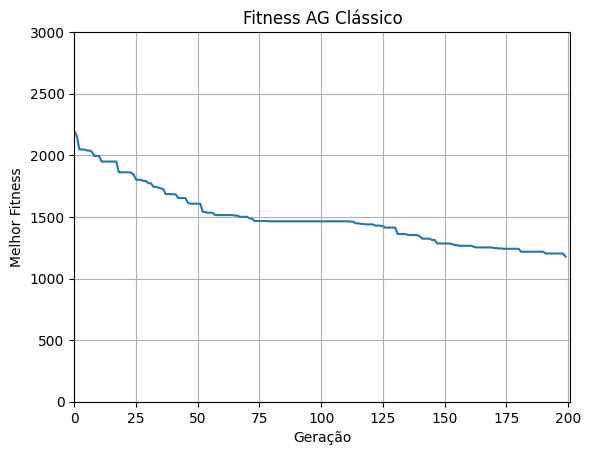

In [19]:
ROOT = os.path.abspath(os.path.join(".."))
caminhho = os.path.join(ROOT, "outputs", "graficos", f"{Juncao}.png")


plt.plot(evolucao.historico["Melhor_fitness"])
plt.xlabel("Geração")
plt.ylabel("Melhor Fitness")
plt.ylim(0, limite_y)
plt.xlim(0, geracao + 1)
plt.title("Fitness " + Nome)
plt.grid(True)
plt.savefig(caminhho,dpi=300, bbox_inches="tight")
plt.show()

In [20]:
Melhor_rota(evolucao,df,tamanho_populacao,Juncao,Nome)

### Resultados

In [21]:
print("\n" + "="*40)
print(f"RESULTADOS - {Nome}")
print("="*40)

print(f"Assimetria:             {assimetria:.4f}")
print(f"Curtose:                {curtose:.4f}")
print(f"Desvio padrão:          {desvio_padrao:.4f}")
print(f"Tempo de execução:      {tempo_de_execucao:.2f} s")
print(f"Gerações até convergir: {Tempo_ate_convergir}")

print("-"*40)
print(f"Melhor fitness:         {min(evo):.4f}")
print(f"Melhor rota encontrada:\n{melhor_rota}")
print("-"*40)
print(f"Ótimo Global:           {(Otimo_global):.4f}")
print(f"Gap:                    {(min(evo) - Otimo_global):.4f}")

print("="*40)


RESULTADOS - AG Clássico
Assimetria:             0.9235
Curtose:                0.1430
Desvio padrão:          235.2056
Tempo de execução:      24.73 s
Gerações até convergir: 199
----------------------------------------
Melhor fitness:         1177.7486
Melhor rota encontrada:
[33 14 56 70 69 59 19  4 68 60 16 39 47 27 20 35 73 40 22 41 72 63  0 61
 21 15 43 17 57 11 31  2 50 53 18 71 38  9 10 64 37 45 25  6 66 12 26 28
 51 36 46 29  5 75  3 44  1 32 62 48 42 55 67 13 52 65 58  7 34 49 23 24
 30 54  8 74]
----------------------------------------
Ótimo Global:           545.3876
Gap:                    632.3610
